# Toy regression communication visualisation

This notebook runs the three-cluster experiment for 30 clients and 30 communication rounds using DAC, oracle, and fully random communication. It saves all three replay timelines and standard diagnostic plots under `Data_for_viz`.

In [79]:
import copy
import importlib
import json
import os
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from utils.classes import Client
from utils.toy_regression_utils import LinearRegression, generate_regression_multi
import utils.training_utils as training_utils
training_utils = importlib.reload(training_utils)
from utils.training_utils import (
    client_information_exchange_DAC,
    client_information_exchange_oracle,
    train_clients_locally,
)

SEED = 1
N_CLIENTS = 30
N_CLUSTERS = 3
CLIENTS_PER_CLUSTER = 10
N_ROUNDS = 50
EXPLORATION_ROUNDS = 3
N_DATA_TRAIN = 50
N_DATA_VAL = 100
BATCH_SIZE = 8
N_LOCAL_EPOCHS = 1
LEARNING_RATE = 0.001
N_NEIGHBORS = 3
SIGMA = 3
TAU = 5000
OUTPUT_DIR = "Data_for_viz"
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
print("Output directory:", os.path.abspath(OUTPUT_DIR))

Output directory: c:\Users\erici\Progg\Decentralized visualized\decentralized_deep_learning\Data_for_viz


In [80]:
def make_dataset(theta, size, sigma=SIGMA):
    x, y = generate_regression_multi(theta, size, sigma)
    return torch.utils.data.TensorDataset(
        torch.from_numpy(x).float(),
        torch.from_numpy(y).float().reshape(-1, 1),
    )

# Fixed, clearly separated regression functions make the three clusters interpretable.
thetas = [
    np.array([8, -8, 4, -4, 2, -2, 1, -1, 0.5, -0.5]),
    np.array([-8, 8, -4, 4, -2, 2, -1, 1, -0.5, 0.5]),
    np.array([6, 6, -6, -6, 3, 3, -3, -3, 1, -1]),
]
trainsets = [
    make_dataset(thetas[cluster], N_DATA_TRAIN)
    for cluster in range(N_CLUSTERS)
    for _ in range(CLIENTS_PER_CLUSTER)
]
valsets = [make_dataset(theta, N_DATA_VAL) for theta in thetas]
initial_model = LinearRegression(10, 1)

def build_clients():
    """Build a fresh, identical client population for each strategy."""
    clients = []
    for client_id in range(N_CLIENTS):
        cluster = client_id // CLIENTS_PER_CLUSTER
        clients.append(Client(
            train_set=trainsets[client_id], val_set=valsets[cluster],
            idxs_train=None, idxs_val=None, criterion=torch.nn.MSELoss(),
            lr=LEARNING_RATE, device=torch.device("cpu"), batch_size=BATCH_SIZE,
            num_users=N_CLIENTS, model=copy.deepcopy(initial_model), idx=client_id,
            stopping_rounds=N_ROUNDS + 1, ratio=1 / N_CLUSTERS,
            dataset="toy_problem", shift=None, theta=thetas[cluster],
        ))
    return clients

clients = build_clients()
print(f"Created {len(clients)} clients in {N_CLUSTERS} clusters")

Created 30 clients in 3 clusters


In [81]:
GUESS_INPUT = torch.tensor([[1.0] + [0.0] * 9])

def average_cluster_guesses(clients):
    """Average each cluster's prediction for the fixed probe input."""
    guesses = []
    for cluster in range(N_CLUSTERS):
        cluster_guesses = []
        for client in clients:
            if client.group == cluster:
                client.local_model.eval()
                with torch.no_grad():
                    cluster_guesses.append(float(client.local_model(GUESS_INPUT).item()))
        guesses.append(float(np.mean(cluster_guesses)))
    return guesses

def similarity_matrix(clients):
    """Return the current client-to-client DAC similarity matrix."""
    return [[float(score) for score in client.similarity_scores] for client in clients]

def snapshot(clients, round_number, communications, include_similarity=False):
    state = {
        "round": round_number,
        "clusterAverageValidationLoss": [
            float(np.mean([c.val_loss_list[-1] for c in clients if c.group == cluster]))
            for cluster in range(N_CLUSTERS)
        ],
        "clusterAverageGuess": average_cluster_guesses(clients),
        "nodes": [
            {"id": str(c.idx), "cluster": c.group, "validationLoss": float(c.val_loss_list[-1])}
            for c in clients
        ],
        "communications": communications,
    }
    if include_similarity:
        state["similarityMatrix"] = similarity_matrix(clients)
    return state

def communication_records(clients):
    records = []
    for client in clients:
        if not client.exchanges_every_round:
            continue
        for peer in client.exchanges_every_round[-1]:
            records.append({
                "source": str(client.idx), "target": str(int(peer)),
                "similarity": float(client.similarity_scores[peer]),
                "sameCluster": client.group == clients[peer].group,
            })
    return records

def reset_uniform_priors(clients):
    """Keep DAC exploration random while still recording similarity information."""
    for client in clients:
        client.priors = np.ones(N_CLIENTS) / (N_CLIENTS - 1)
        client.priors[client.idx] = 0


def run_strategy(strategy, seed_offset):
    """Run one strategy from the same initial model and data."""
    np.random.seed(SEED + seed_offset)
    random.seed(SEED + seed_offset)
    torch.manual_seed(SEED + seed_offset)
    clients = build_clients()
    clients = train_clients_locally(clients, N_LOCAL_EPOCHS, verbose=False)
    states = [snapshot(clients, 0, [], include_similarity=strategy == "dac")]
    dac_parameters = {
        "nbr_neighbors_sampled": N_NEIGHBORS, "prior_update_rule": "softmax",
        "similarity_metric": "inverse_training_loss", "tau": TAU,
        "cosine_alpha": 0.0, "mergatron": "chill",
        "aggregation_weighting": "priors",
        "dataset": "toy_problem", "minmax": False,
    }
    exchange_parameters = {
        "nbr_neighbors_sampled": N_NEIGHBORS, "mergatron": "chill",
    }
    for round_number in range(N_ROUNDS):
        if strategy == "dac":
            if round_number < EXPLORATION_ROUNDS:
                reset_uniform_priors(clients)
            clients = client_information_exchange_DAC(
                clients, dac_parameters, verbose=False, round=round_number
            )
        elif strategy == "oracle":
            clients = client_information_exchange_oracle(
                clients, exchange_parameters, verbose=False,
                round=round_number, delusion=0,
            )
        else:
            clients = client_information_exchange_oracle(
                clients, exchange_parameters, verbose=False,
                round=round_number, delusion=-1,
            )
        communications = communication_records(clients)
        clients = train_clients_locally(clients, N_LOCAL_EPOCHS, verbose=False)
        states.append(snapshot(
            clients,
            round_number + 1,
            communications,
            include_similarity=strategy == "dac",
        ))
    return clients, states, dac_parameters if strategy == "dac" else exchange_parameters

results = {}
final_clients_by_strategy = {}
for strategy in ["dac", "oracle", "random"]:
    clients, states, strategy_parameters = run_strategy(
        strategy,
        [0, 100, 200][["dac", "oracle", "random"].index(strategy)],
    )
    results[strategy] = {"states": states, "parameters": strategy_parameters}
    final_clients_by_strategy[strategy] = clients
    with open(os.path.join(OUTPUT_DIR, f"toy_regression_{strategy}_clients.pkl"), "wb") as file:
        pickle.dump(clients, file)
    print(f"{strategy}: {len(states)} states, {sum(len(s['communications']) for s in states)} communication events")

replays = {
    "experiment": "toy_regression_30_clients_three_strategies",
    "commonParameters": {
        "clients": N_CLIENTS, "clusters": N_CLUSTERS,
        "clientsPerCluster": CLIENTS_PER_CLUSTER, "rounds": N_ROUNDS,
        "explorationRounds": EXPLORATION_ROUNDS, "learningRate": LEARNING_RATE,
        "noiseSigma": SIGMA, "neighborsSampled": N_NEIGHBORS,
        "selfWeight": None,
        "guessInput": GUESS_INPUT.tolist(),
        "targetGuesses": [float(theta[0]) for theta in thetas],
    },
    "strategies": results,
}
with open(os.path.join(OUTPUT_DIR, "toy_regression_three_strategies.json"), "w", encoding="utf-8") as file:
    json.dump(replays, file, indent=2)
print("Saved all three strategy replays")

dac: 51 states, 4500 communication events
oracle: 51 states, 4500 communication events
random: 51 states, 4500 communication events
Saved all three strategy replays


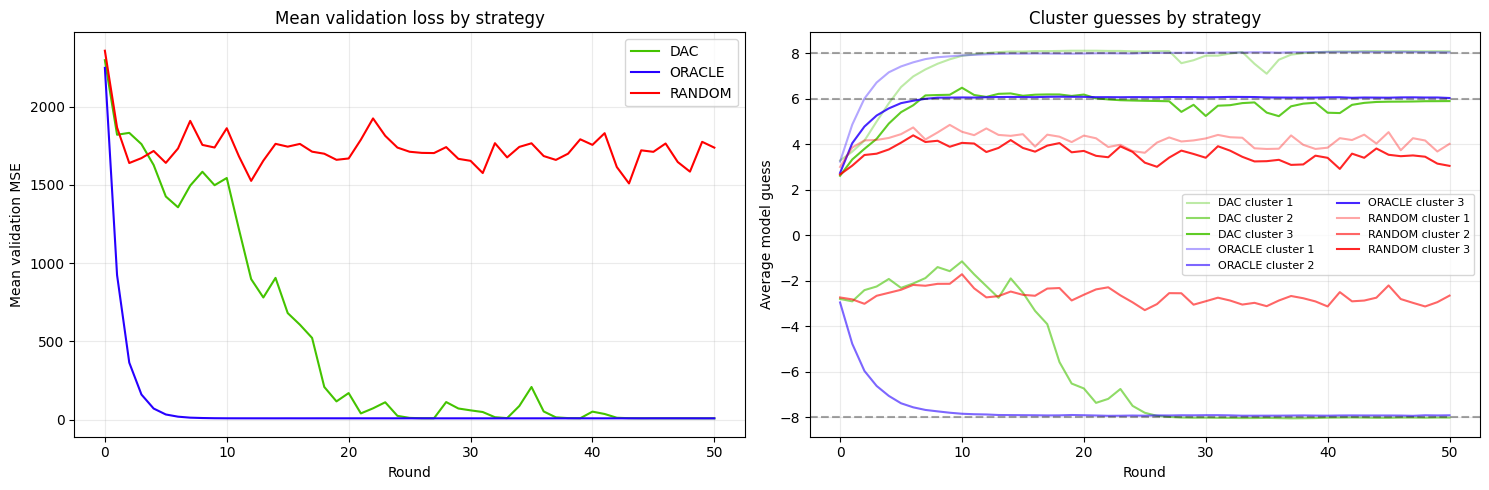

In [82]:
strategy_colors = {"dac": "#44C300", "oracle": "#2600FF", "random": "#FF0000"}
rounds = np.array([state["round"] for state in results["dac"]["states"]])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for strategy, result in results.items():
    losses = np.array([state["clusterAverageValidationLoss"] for state in result["states"]])
    guesses = np.array([state["clusterAverageGuess"] for state in result["states"]])
    axes[0].plot(rounds, losses.mean(axis=1), label=strategy.upper(), color=strategy_colors[strategy])
    for cluster in range(N_CLUSTERS):
        axes[1].plot(rounds, guesses[:, cluster], label=f"{strategy.upper()} cluster {cluster + 1}", color=strategy_colors[strategy], alpha=0.35 + cluster * 0.25)
for cluster, target in enumerate([float(theta[0]) for theta in thetas]):
    axes[1].axhline(target, linestyle="--", color="black", alpha=0.35)
axes[0].set_xlabel("Round"); axes[0].set_ylabel("Mean validation MSE"); axes[0].set_title("Mean validation loss by strategy")
axes[1].set_xlabel("Round"); axes[1].set_ylabel("Average model guess"); axes[1].set_title("Cluster guesses by strategy")
axes[0].legend(); axes[1].legend(ncol=2, fontsize=8); axes[0].grid(alpha=0.25); axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "strategy_comparison.png"), dpi=160)
plt.show()

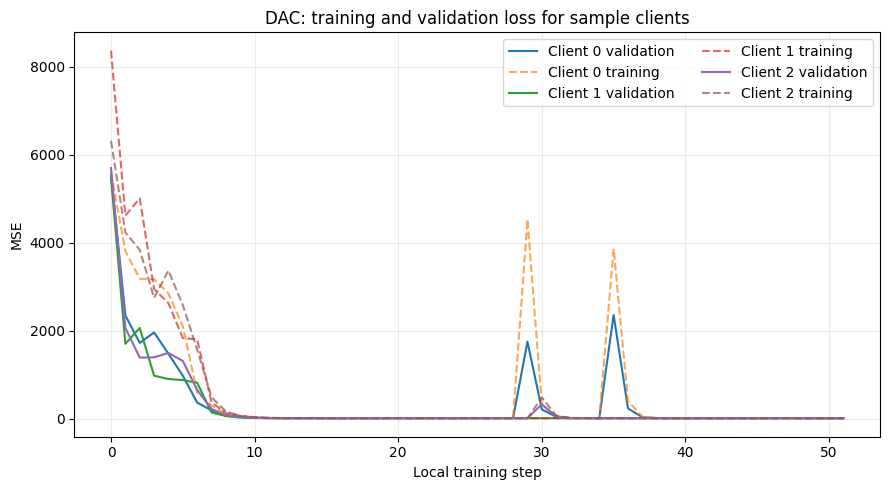

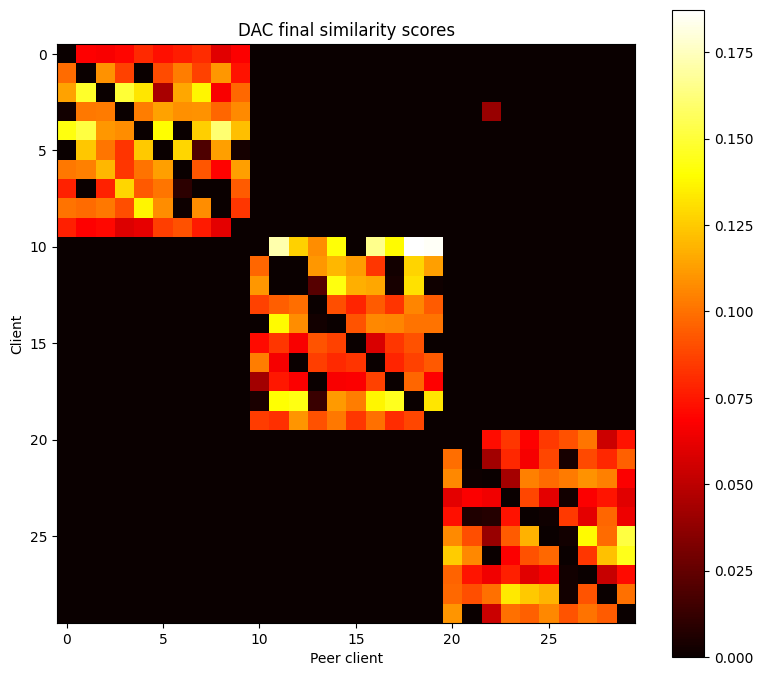

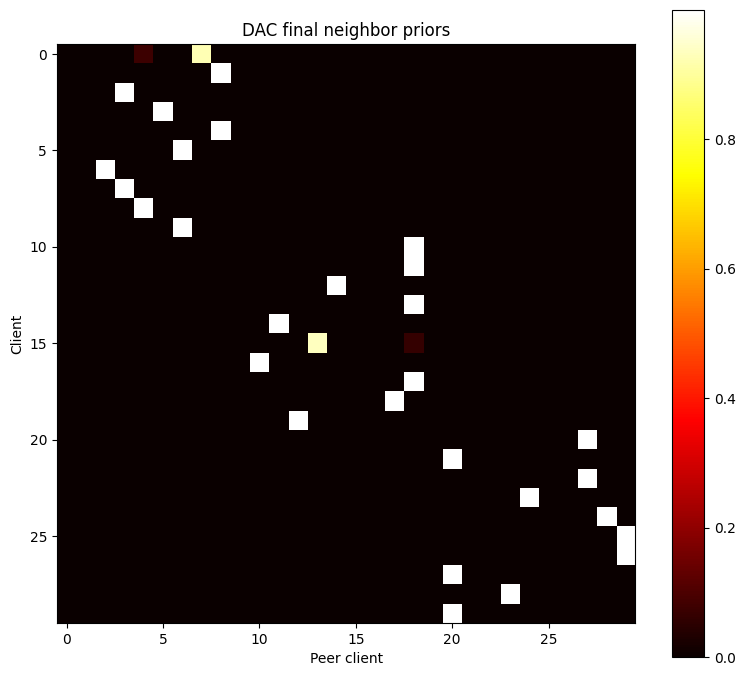

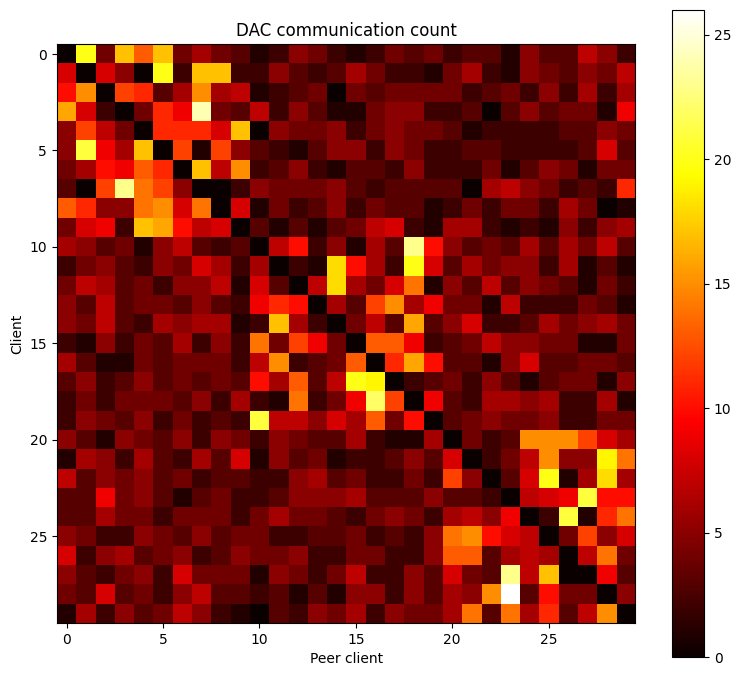

In [83]:
dac_clients = final_clients_by_strategy["dac"]

plt.figure(figsize=(9, 5))
for client in dac_clients[:3]:
    plt.plot(client.val_loss_list, label=f"Client {client.idx} validation")
    plt.plot(client.train_loss_list, linestyle="--", alpha=0.7, label=f"Client {client.idx} training")
plt.xlabel("Local training step"); plt.ylabel("MSE"); plt.title("DAC: training and validation loss for sample clients")
plt.legend(ncol=2); plt.grid(alpha=0.25); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "dac_sample_client_training_validation_loss.png"), dpi=160)
plt.show()

def heatmap(matrix, title, filename):
    plt.figure(figsize=(8, 7)); plt.imshow(matrix, cmap="hot", interpolation="nearest"); plt.colorbar()
    plt.title(title); plt.xlabel("Peer client"); plt.ylabel("Client"); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=160); plt.show()

similarity_matrix = np.array([client.similarity_scores for client in dac_clients])
prior_matrix = np.array([client.priors for client in dac_clients])
sampled_matrix = np.array([client.n_sampled for client in dac_clients])
heatmap(similarity_matrix, "DAC final similarity scores", "dac_final_similarity_heatmap.png")
heatmap(prior_matrix, "DAC final neighbor priors", "dac_final_neighbor_prior_heatmap.png")
heatmap(sampled_matrix, "DAC communication count", "dac_communication_count_heatmap.png")

The strategy comparison plot shows mean validation loss and the cluster guesses for DAC, oracle, and random communication. The average cluster guess is each cluster's mean prediction for the fixed probe input `[1, 0, ..., 0]`; dashed lines are the target values. DAC keeps 50 percent of each local model and distributes the other 50 percent between three neighbors according to their similarity-derived priors. Each strategy is run from the same data and initial model, and its complete states are stored in `toy_regression_three_strategies.json` for later website toggling. The heatmaps use the final DAC clients as a communication sanity check.